<a href="https://colab.research.google.com/github/bedkemanojkumar/mini-ml-projects-for-practice/blob/main/G39_assignment03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Data ────────────────────────────────────────────────────
data = {
    "age": [25, None, 30, 200, 40, 22, 27, None, 35, 120, 29, 31, None, 45, 50, -5, 38, None, 60, 33],
    "salary": [50000, 60000, None, 70000, 10000000, 45000, None, 52000, 58000, 62000,
               49000, None, 75000, 80000, None, 30000, 1200000, 54000, None, 61000],
    "experience": [2, 5, 3, 10, None, 1, 4, 6, None, 15, 2, 3, 7, None, 20, -1, 8, 9, None, 5],
    "department": ["Sales","HR","IT","IT",None,"Sales","HR","IT","Finance","Finance",
                   "Sales",None,"IT","HR","Finance","Sales","Unknown","IT",None,"HR"],
    "joining_date": ["2020-01-01","2019-05-10",None,"2021-07-15","invalid_date",
                     "2018-03-20","2022-11-11",None,"2020-06-01","2017-09-09",
                     "2019-12-12","wrong_format","2021-01-01",None,"2016-04-04",
                     "2015-08-08","2023-02-02",None,"2020-10-10","2018-07-07"],
    "performance_score": [3.5, 4.0, None, 5.0, 2.0, 3.0, None, 4.5, 3.8, 4.2,
                          None, 3.3, 4.1, None, 4.8, 2.5, 3.9, None, 4.0, 3.7],
    "churn": ["No","No","No","No","Yes","No","No","No","No","Yes",
              "No","No","No","No","Yes","No","No","No","No","Yes"]
}
df = pd.DataFrame(data)
NUM_COLS = ['age', 'salary', 'experience', 'performance_score']



In [ ]:
# check missing values

In [17]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
print(missing)

age                  0
salary               0
experience           0
department           0
joining_date         0
performance_score    0
churn                0
dtype: int64


In [18]:
# fix missing values

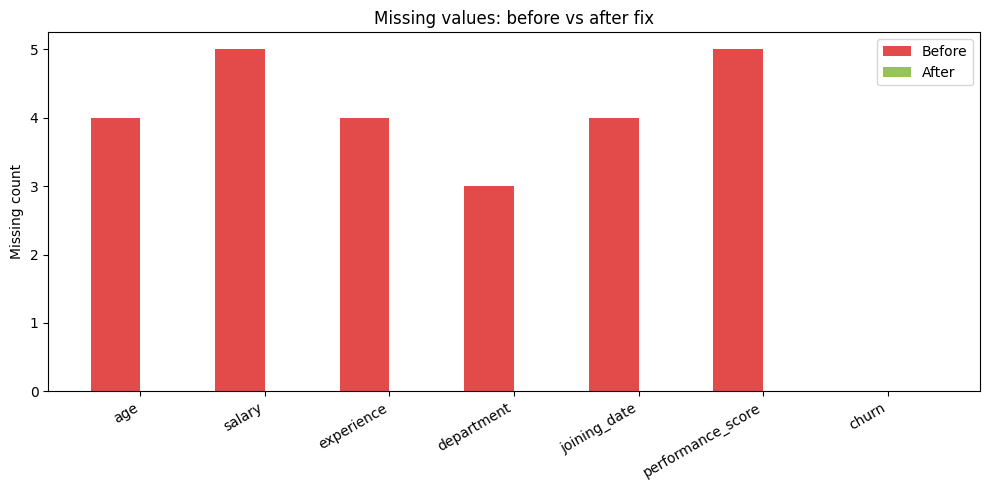

In [10]:
df = pd.DataFrame(data)
before = df.isnull().sum()
df["age"].fillna(df["age"].median(), inplace=True)
df["salary"].fillna(df["salary"].median(), inplace=True)
df["experience"].fillna(df["experience"].median(), inplace=True)
df["department"].replace("Unknown", np.nan, inplace=True)
df["department"].fillna(df["department"].mode()[0], inplace=True)
df["joining_date"] = pd.to_datetime(df["joining_date"], errors="coerce")
df["joining_date"].fillna(method="ffill", inplace=True)
df["performance_score"].fillna(df["performance_score"].median(), inplace=True)

after = df.isnull().sum()
# Plot
cols = list(before.index)
x = np.arange(len(cols))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, before, 0.4, label="Before", color="#E24B4A")
ax.bar(x + 0.2, after,  0.4, label="After",  color="#97C459")
ax.set_xticks(x)
ax.set_xticklabels(cols, rotation=30, ha="right")
ax.set_ylabel("Missing count")
ax.set_title("Missing values: before vs after fix")
ax.legend()
plt.tight_layout()
plt.show()


In [2]:
# Detect Outliers

In [11]:
for col in NUM_COLS:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

In [14]:
# Cap outliers
df[col] = np.where(df[col] < lower, lower,
               np.where(df[col] > upper, upper, df[col]))

In [ ]:
#  plot

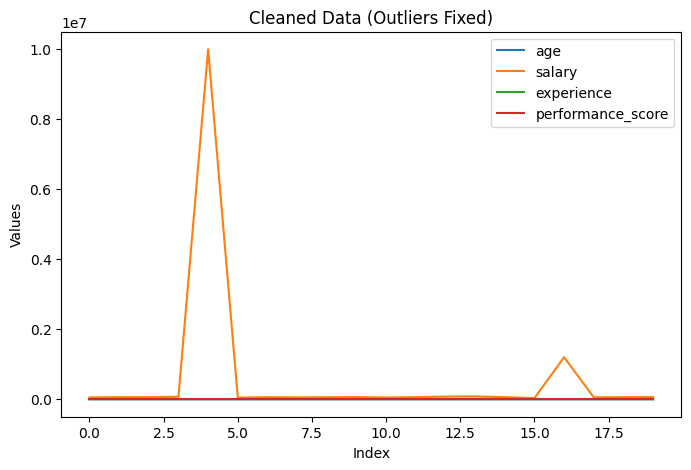

In [16]:
plt.figure(figsize=(8,5))

for col in NUM_COLS :
    plt.plot(df[col], label=col)

plt.legend()
plt.title("Cleaned Data (Outliers Fixed)")
plt.xlabel("Index")
plt.ylabel("Values")

plt.show()

In [ ]:
# Class Balance using Churn

In [19]:
from sklearn.utils import resample

# Separate classes
df_majority = df[df["churn"] == "No"]
df_minority = df[df["churn"] == "Yes"]

# Oversample minority
df_minority_upsampled = resample(df_minority,
                                replace=True,
                                n_samples=len(df_majority),
                                random_state=42)

# Combine back
df_balanced = pd.concat([df_majority, df_minority_upsampled])

# Shuffle
df_balanced = df_balanced.sample(frac=1, random_state=42)

print(df_balanced["churn"].value_counts())

churn
Yes    16
No     16
Name: count, dtype: int64
